# Dataset Analysis — SemEval 2025 Task 10 (Subtask 2)

Exploratory analysis of the news-article dataset used for **multi-label narrative
and subnarrative classification**. The articles cover two domains — the
**Ukraine-Russia War (URW)** and **Climate Change (CC)** — in two languages,
**English (EN)** and **Portuguese (PT)**.

## Data folder structure

```text
data/
├── training_data_16_October_release/   # labelled training data
│   ├── EN/
│   │   ├── raw-documents/              # article text files (one .txt per article)
│   │   ├── subtask-1-annotations.txt
│   │   ├── subtask-2-annotations.txt   # <- labels used in this project
│   │   └── subtask-3-annotations.txt
│   └── PT/                             # same layout as EN
└── target_4_December_release/          # dev/test articles used for inference
    ├── EN/                             # same layout as the training release
    └── PT/
```

Each `subtask-2-annotations.txt` is **tab-separated** with three columns:

```text
article_id <TAB> narrative_labels <TAB> subnarrative_labels
```

* multiple labels are separated by `;`
* subnarratives are written as `Narrative: Subnarrative`
  (e.g. `URW: Discrediting Ukraine: Discrediting Ukrainian military`)

This notebook covers, in order: the folder/file inventory, the annotation format
and label distribution, per-language corpus statistics (tokenization, stopword
removal, lemmatization, word frequencies, word clouds), and an English-vs-Portuguese
comparison. The corpus statistics in Section 3 of the project report were computed
on the `target_4_December_release` documents, so the same folder is used here.

In [1]:
from pathlib import Path
from collections import Counter
from statistics import mean

import nltk
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize

# One-time NLTK resource downloads (no-ops on re-run)
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
                 "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(resource, quiet=True)

DATA_DIR = Path("..") / "data"
TRAIN_DIR = DATA_DIR / "training_data_16_October_release"  # labelled training data
TARGET_DIR = DATA_DIR / "target_4_December_release"        # articles used for inference

## 1. Folder overview and file counts

A quick inventory of both releases: number of articles and the annotation files
available per language.

In [2]:
for release in sorted(p for p in DATA_DIR.iterdir() if p.is_dir()):
    print(release.name)
    for lang_dir in sorted(p for p in release.iterdir() if p.is_dir()):
        n_docs = len(list((lang_dir / "raw-documents").glob("*.txt")))
        annotation_files = ", ".join(p.name for p in sorted(lang_dir.glob("*.txt")))
        print(f"  {lang_dir.name}: {n_docs} articles | {annotation_files}")

target_4_December_release
  EN: 399 articles | subtask-1-annotations.txt, subtask-2-annotations.txt, subtask-3-annotations.txt
  PT: 400 articles | subtask-1-annotations.txt, subtask-2-annotations.txt, subtask-3-annotations.txt
training_data_16_October_release
  EN: 200 articles | subtask-1-annotations.txt, subtask-2-annotations.txt, subtask-3-annotations.txt
  PT: 200 articles | subtask-1-annotations.txt, subtask-2-annotations.txt, subtask-3-annotations.txt


## 2. Annotations and label distribution

We load the subtask-2 annotations of the **training release** and look at how the
narrative labels are distributed. This shows the class imbalance that motivated
the use of focal loss and weighted sampling during training.

In [3]:
def load_annotations(path):
    """Load a subtask-2 annotation file (tab-separated, no header)."""
    return pd.read_csv(path, sep="\t", header=None,
                       names=["article_id", "narratives", "subnarratives"])

ann_en = load_annotations(TRAIN_DIR / "EN" / "subtask-2-annotations.txt")
ann_pt = load_annotations(TRAIN_DIR / "PT" / "subtask-2-annotations.txt")
ann_en.head()

,article_id,narratives,subnarratives
0,EN_UA_103861.txt,Other,Other
1,EN_UA_103667.txt,Other,Other
2,EN_UA_021270.txt,URW: Speculating war outcomes;URW: Discreditin...,URW: Speculating war outcomes: Other;URW: Disc...
3,EN_UA_103403.txt,Other,Other
4,EN_CC_100145.txt,Other,Other


In [4]:
def label_counts(column):
    """Count individual labels in a ';'-separated label column."""
    return Counter(label.strip()
                   for entry in column
                   for label in str(entry).split(";") if label.strip())

for name, ann in [("English", ann_en), ("Portuguese", ann_pt)]:
    narratives = label_counts(ann["narratives"])
    subnarratives = label_counts(ann["subnarratives"])
    labels_per_article = ann["narratives"].map(lambda x: len(str(x).split(";")))
    print(f"{name}: {len(ann)} annotated articles | "
          f"{len(narratives)} unique narratives | "
          f"{len(subnarratives)} unique subnarratives | "
          f"{labels_per_article.mean():.2f} narrative labels per article on average")

English: 200 annotated articles | 21 unique narratives | 71 unique subnarratives | 2.04 narrative labels per article on average
Portuguese: 200 annotated articles | 20 unique narratives | 66 unique subnarratives | 2.63 narrative labels per article on average


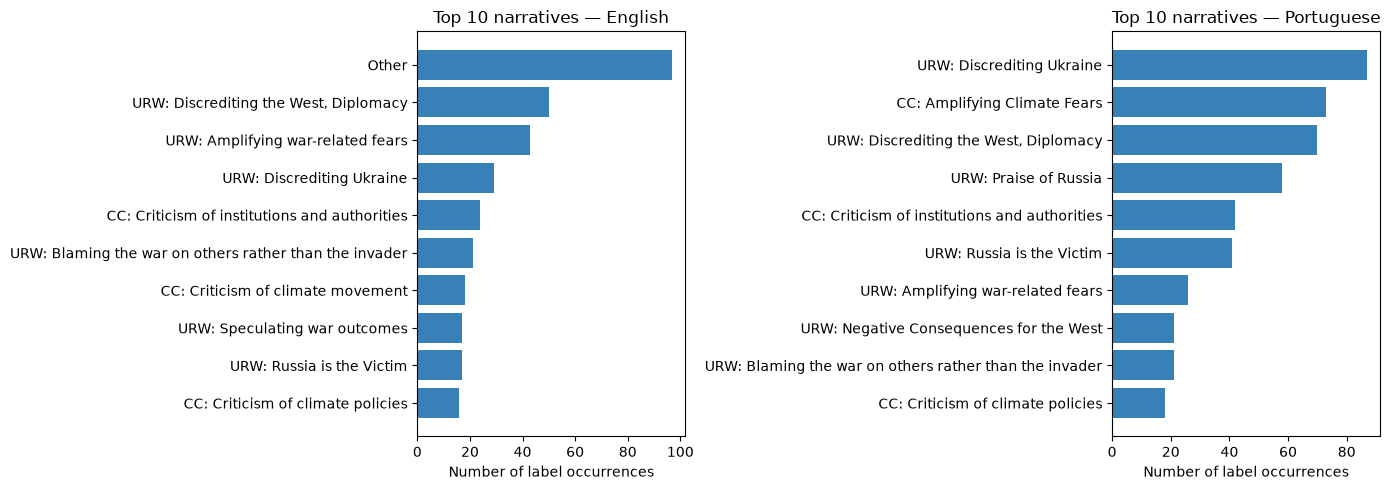

In [5]:
# Top-10 most frequent narrative labels per language
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, ann) in zip(axes, [("English", ann_en), ("Portuguese", ann_pt)]):
    top = label_counts(ann["narratives"]).most_common(10)
    labels = [label for label, _ in top][::-1]
    counts = [count for _, count in top][::-1]
    ax.barh(labels, counts, color="#3781B7")
    ax.set_title(f"Top 10 narratives — {name}")
    ax.set_xlabel("Number of label occurrences")
plt.tight_layout()
plt.show()

## 3. Corpus statistics

Preprocessing pipeline applied to every article (as described in the report):

1. **Sentence tokenization** (NLTK `sent_tokenize`)
2. **Word tokenization** (NLTK `word_tokenize`)
3. **Lowercasing** and keeping only alphanumeric tokens
4. **Stopword removal** (language-specific NLTK stopword lists)
5. **Normalization** — English words are lemmatized with the WordNet lemmatizer
   (using POS tags for accuracy). NLTK has no Portuguese lemmatizer, and stemming
   produces unreadable truncated forms, so the Portuguese analysis keeps the
   stopword-filtered surface forms.

From this we derive: total words, vocabulary size, total sentences, average
sentence length (in tokens) and average word length (in characters).

In [6]:
def corpus_stats(directory, language):
    """Tokenize all .txt articles in `directory`; return (stats dict, filtered words)."""
    stop_words = set(stopwords.words(language))
    n_sentences = 0
    sentence_lengths, words = [], []

    for path in sorted(directory.glob("*.txt")):
        text = path.read_text(encoding="utf-8")
        sentences = sent_tokenize(text, language=language)
        n_sentences += len(sentences)
        sentence_lengths += [len(word_tokenize(s, language=language)) for s in sentences]
        tokens = word_tokenize(text, language=language)
        words += [t.lower() for t in tokens
                  if t.isalnum() and t.lower() not in stop_words]

    stats = {
        "Total Words": len(words),
        "Vocabulary Size": len(set(words)),
        "Total Sentences": n_sentences,
        "Avg Sentence Length": round(mean(sentence_lengths), 2),
        "Avg Word Length": round(mean(len(w) for w in words), 2),
    }
    return stats, words


def lemmatize_english(words):
    """WordNet lemmatization guided by POS tags (tagged in one batch for speed)."""
    lemmatizer = WordNetLemmatizer()
    pos_map = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return [lemmatizer.lemmatize(word, pos_map.get(tag[0], wordnet.NOUN))
            for word, tag in nltk.pos_tag(words)]


def plot_top_words(words, title, n=10):
    """Bar chart of the n most frequent words."""
    top = Counter(words).most_common(n)
    plt.figure(figsize=(10, 5))
    bars = plt.bar([w for w, _ in top], [c for _, c in top], color="#3781B7")
    plt.bar_label(bars)
    plt.title(title)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.gca().spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_wordcloud(words, title):
    """Word cloud of the given word list."""
    cloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(words))
    plt.figure(figsize=(10, 5))
    plt.imshow(cloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

### 3.1 English

In [7]:
stats_en, words_en = corpus_stats(TARGET_DIR / "EN" / "raw-documents", "english")
words_en = lemmatize_english(words_en)
words_en = [w for w in words_en if w != "u"]  # drop tokenizer artefact from "U.S."
pd.Series(stats_en, name="English")

Total Words            110049.00
Vocabulary Size         15133.00
Total Sentences          7821.00
Avg Sentence Length        28.12
Avg Word Length             6.50
Name: English, dtype: float64

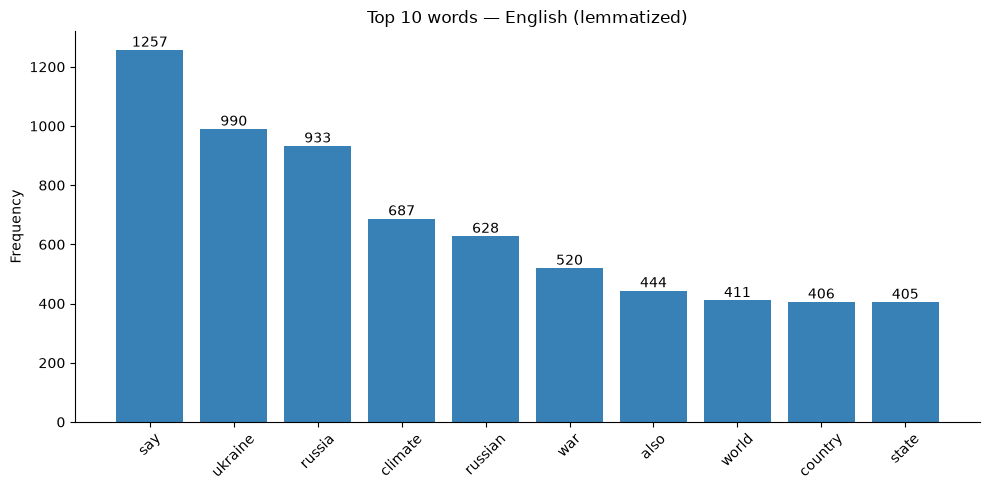

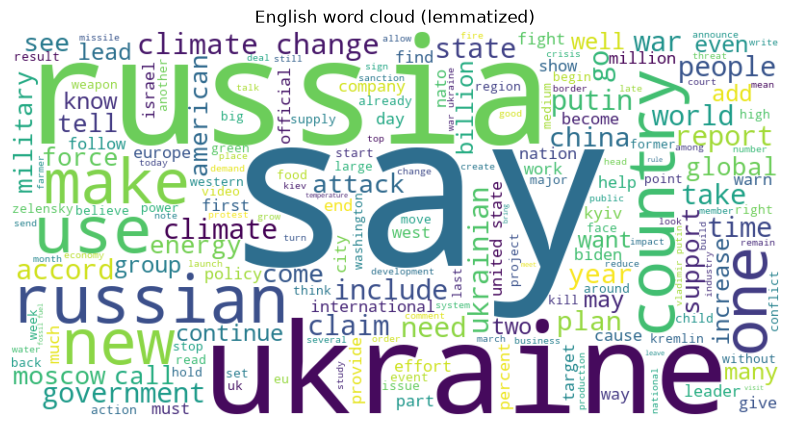

In [8]:
plot_top_words(words_en, "Top 10 words — English (lemmatized)")
plot_wordcloud(words_en, "English word cloud (lemmatized)")

### 3.2 Portuguese

In [9]:
stats_pt, words_pt = corpus_stats(TARGET_DIR / "PT" / "raw-documents", "portuguese")
pd.Series(stats_pt, name="Portuguese")

Total Words            88234.00
Vocabulary Size        14078.00
Total Sentences         5803.00
Avg Sentence Length       30.87
Avg Word Length            7.09
Name: Portuguese, dtype: float64

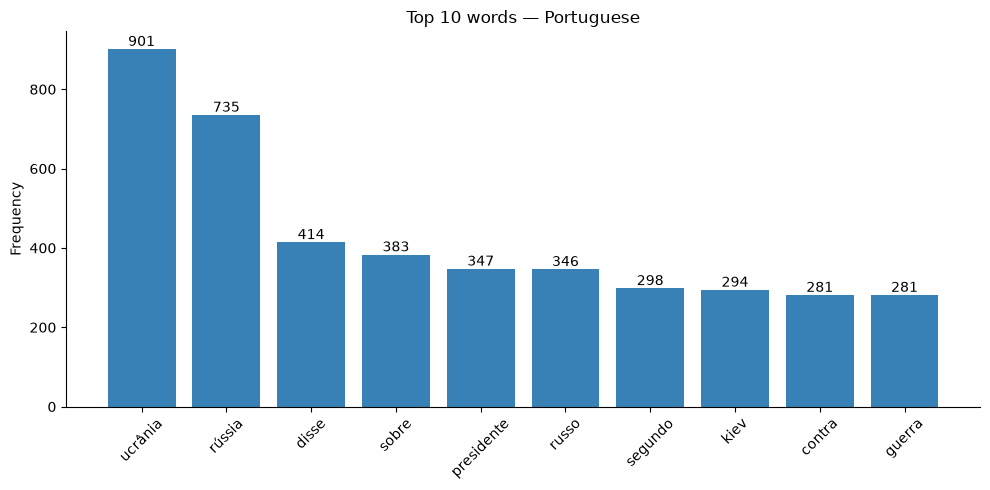

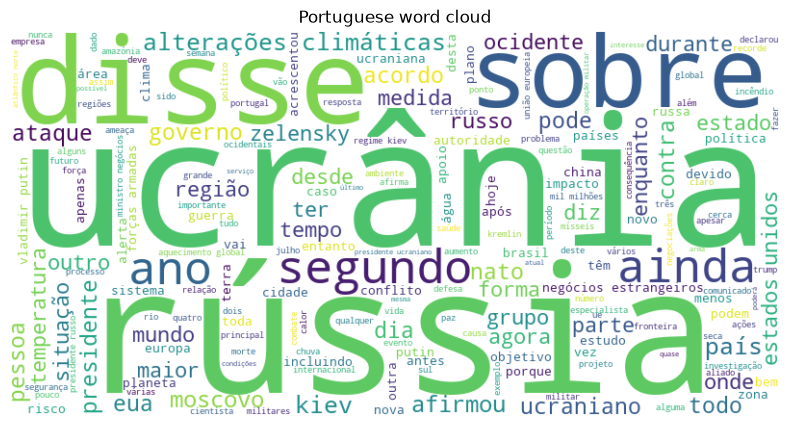

In [10]:
plot_top_words(words_pt, "Top 10 words — Portuguese")
plot_wordcloud(words_pt, "Portuguese word cloud")

## 4. English vs Portuguese comparison

The statistics computed above, side by side. A log scale is used because the
count metrics and the average-length metrics differ by several orders of magnitude.

In [11]:
comparison = pd.DataFrame({"English": stats_en, "Portuguese": stats_pt})
comparison

,English,Portuguese
Total Words,110049.00,88234.00
Vocabulary Size,15133.00,14078.00
Total Sentences,7821.00,5803.00
Avg Sentence Length,28.12,30.87
Avg Word Length,6.50,7.09


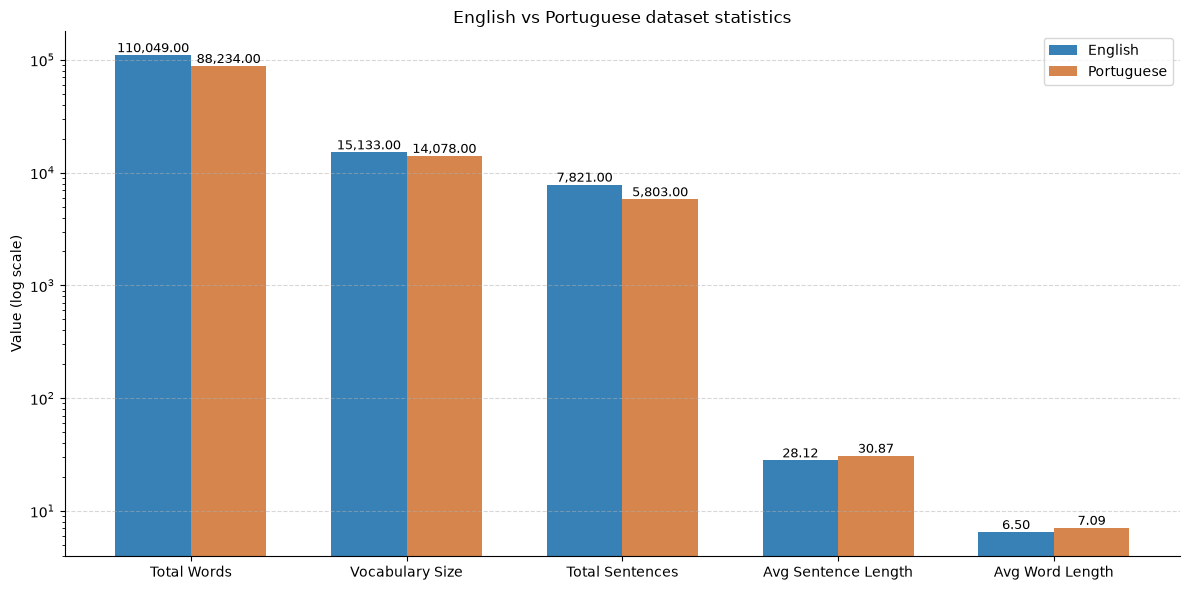

In [12]:
import numpy as np

x = np.arange(len(comparison.index))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_yscale("log")
bars_en = ax.bar(x - width / 2, comparison["English"], width,
                 label="English", color="#3781B7")
bars_pt = ax.bar(x + width / 2, comparison["Portuguese"], width,
                 label="Portuguese", color="#D6854C")
ax.bar_label(bars_en, fmt="{:,.2f}", fontsize=9)
ax.bar_label(bars_pt, fmt="{:,.2f}", fontsize=9)
ax.set_xticks(x, comparison.index)
ax.set_ylabel("Value (log scale)")
ax.set_title("English vs Portuguese dataset statistics")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Summary

* Both releases are balanced across languages in article count, but the English
  corpus contains more text overall (more words and sentences).
* Portuguese articles have **longer sentences** and **longer words** on average,
  which is consistent with the morphology of the language.
* The most frequent words in both languages directly reflect the two dataset
  domains: the Ukraine-Russia war (e.g. *ukraine*, *russia*, *war* / *ucrânia*,
  *rússia*, *guerra*) and climate change (*climate*, *change* / *clima*,
  *alterações climáticas*).
* The narrative label distribution is heavily imbalanced — a few narratives
  (and the `Other` class) dominate, which motivates the focal loss, positive
  class weighting and weighted sampling used in `src/training.py`.